## TFBS enrichment analysis

Which transcription factor binding sites (TFBS) are enriched for overlap with
significant NGN2 MPRA variants, and is a predicted gain/loss of TF binding
consistently associated with an activating or repressing effect on activity?

Two independent TFBS-overlap annotations are used throughout and compared:
- **ReMap2022**: ChIP-seq-derived TF binding site overlap (`has_remap2022_TFBS_overlap`)
- **HOCOMOCOv13 + FIMO ("bitscore")**: motif-disruption scoring, ALT vs REF bit
  score (`local_bitscore_*` columns), thresholded at the 80th percentile of
  |delta bit score| (`hocomoco_tfbs_disruption_q80`, computed upstream)

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

sys.path.append("../00_helpful_functions")
import helpful_functions as hf

sns.set_style("whitegrid")



### Load the master variant/TFBS annotation table

This is a fresh, independent load (the original notebook did the same reset at
this point) - none of the earlier support-enrichment/duplicate-QC state is needed.

In [2]:
variant_info_with_tfbs_annotation_path = "data/2602_combined_variant_info_80k_tested_NGN2_tfbs_h13_remap2022.tsv.gz"
NGN2_variants_with_gwas_tested = pd.read_csv(
    variant_info_with_tfbs_annotation_path,
    sep="\t",
    low_memory=False,
)

# eval list-like columns (stored as stringified lists) back into real Python lists
example_row = NGN2_variants_with_gwas_tested.loc[
    NGN2_variants_with_gwas_tested["ID"]
    == "cardiac_neuro_cava_random:ALT_SKI|ENSG00000157933.11|EH38E2778506_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E2778506|1-2198007-C-G"
].iloc[0]
list_list_cols = [
    col
    for col in NGN2_variants_with_gwas_tested.columns
    if example_row[col] and isinstance(example_row[col], str) and "[" in example_row[col]
]
print(list_list_cols)

for col in list_list_cols:
    NGN2_variants_with_gwas_tested[col] = NGN2_variants_with_gwas_tested[col].apply(hf.safe_eval)

['enformer_classes_list', 'gene_set', 'REMAP2022_TFBS_list']


In [3]:
print("Total variants:", NGN2_variants_with_gwas_tested.shape[0])
print(f"Number of different variants: {NGN2_variants_with_gwas_tested['SPDI'].nunique()}")

Total variants: 38968
Number of different variants: 38684


In [4]:
# unique-variant effect direction breakdown (dedup by largest |logFC| per SPDI)
ngn2_variant_effects_df = NGN2_variants_with_gwas_tested.copy()
ngn2_variant_effects_df["abs_logFC"] = ngn2_variant_effects_df["NGN2_variant_logFC"].abs()
unique_ngn2_variant_effects = (
    ngn2_variant_effects_df.sort_values("abs_logFC", ascending=False)
    .drop_duplicates("SPDI")
    .copy()
)
n_significant = unique_ngn2_variant_effects["NGN2_variant_is_significant"].sum()
print(
    f"Unique variants with significant effect: {n_significant} / "
    f"{unique_ngn2_variant_effects.shape[0]} "
    f"({100 * n_significant / unique_ngn2_variant_effects.shape[0]:.2f}%)"
)

unique_ngn2_variant_effects["effect_direction"] = unique_ngn2_variant_effects.apply(
    lambda row: (
        "positive"
        if (row["NGN2_variant_is_significant"] & (row["NGN2_variant_logFC"] > 0))
        else "negative"
        if (row["NGN2_variant_is_significant"] & (row["NGN2_variant_logFC"] < 0))
        else "neutral"
    ),
    axis=1,
)
print(unique_ngn2_variant_effects["effect_direction"].value_counts())
print(
    unique_ngn2_variant_effects.groupby("NGN2_variant_is_significant")["effect_direction"]
    .value_counts(normalize=True)
)

Unique variants with significant effect: 1016 / 38684 (2.63%)
effect_direction
neutral     37668
positive      603
negative      413
Name: count, dtype: int64
NGN2_variant_is_significant  effect_direction
False                        neutral             1.000000
True                         positive            0.593504
                             negative            0.406496
Name: proportion, dtype: float64


In [ ]:
sig_NGN2_variants_with_gwas_tested = NGN2_variants_with_gwas_tested[
    NGN2_variants_with_gwas_tested["NGN2_variant_is_significant"]
].copy()
print(f"Number of significant variants: {sig_NGN2_variants_with_gwas_tested.shape[0]}")
print(
    "Number of unique SPDIs among significant variants: "
    f"{sig_NGN2_variants_with_gwas_tested['SPDI'].nunique()}"
)

Number of significant variants: 1018
Number of unique SPDIs among significant variants: 1016


In [ ]:
# optional: export the ReMap2022 overlap columns alone
remap_2022_overlap_80k_MPRA_columns = [
    "SPDI", "ID", "rsid", "variant_pos", "pos",
    "NGN2_variant_adj_p-value", "NGN2_variant_logFC",
    "remap2022_TFBS_name_variant_overlapping", "remap2022_TFBS_cell_type",
    "remap2022_summit_start", "remap2022_summit_end",
    "has_remap2022_TFBS_overlap", "remap2022_nTPM_brain",
]
output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/results/variant_info/remap2022_variant_overlap/2602_remap2022_80k_overlap.tsv.gz"
writing = False
if writing:
    NGN2_variants_with_gwas_tested[remap_2022_overlap_80k_MPRA_columns].to_csv(
        output_path, sep="\t", index=False
    )



### Annotate with the local TFBS variant interpretation

For each variant with a HOCOMOCOv13 motif hit, interpret whether the predicted
change in TF binding (bitscore delta, ALT - REF) together with the observed MPRA
effect (logFC) implies the TF acts as an activator or a repressor at this site.

In [ ]:
def interprete_tf_role_from_mpra_and_bitscore(mpra_logfc, bitscore_delta):
    """
    Interpret TF role based on MPRA logFC and bitscore delta.
    mpra_logfc > 0 means increased expression, bitscore_delta > 0 means increased TF binding.
    """
    if pd.isna(bitscore_delta):
        return "no_tfbs_annotation"
    if pd.isna(mpra_logfc):
        raise ValueError("Measured effect is NaN")
    if bitscore_delta > 0:  # gain of TF binding
        if mpra_logfc > 0:
            return "activating_TF_effect"
        elif mpra_logfc < 0:
            return "repressing_TF_effect"
    elif bitscore_delta < 0:  # loss of TF binding
        if mpra_logfc > 0:
            return "repressing_TF_effect"
        elif mpra_logfc < 0:
            return "activating_TF_effect"
    return "no_effect_or_unclear"


NGN2_variants_with_gwas_tested["TF_role_interpretation"] = NGN2_variants_with_gwas_tested.apply(
    lambda row: interprete_tf_role_from_mpra_and_bitscore(
        row["NGN2_variant_logFC"], row["local_bitscore_delta_local_bit_score"]
    ),
    axis=1,
)



### Per-TF enrichment: are specific TFs' binding sites over-represented among significant variants?

Same Fisher's-exact-test recipe applied to both TFBS-overlap annotations (ReMap2022
and HOCOMOCOv13/bitscore) - refactored into one shared helper instead of the
original's two near-identical copy-pasted blocks.

In [ ]:
def compute_tf_enrichment_fisher(df0, tf_col, min_hits=5):
    """
    For each TF in `tf_col`, Fisher's-exact-test the overlap between
    (variant is significant) and (variant overlaps this TF's binding site),
    restricted to variants with a readout. Returns one row per TF with >= min_hits
    total (sig + non-sig) overlapping variants.
    """
    df0 = df0.copy()
    df0["NGN2_variant_is_significant"] = df0["NGN2_variant_is_significant"].astype(bool)

    sig = df0[df0["NGN2_variant_is_significant"]]
    ns = df0[~df0["NGN2_variant_is_significant"]]

    tf_sig_counts = sig.groupby(tf_col)["ID"].nunique()
    tf_ns_counts = ns.groupby(tf_col)["ID"].nunique()

    N_sig = sig["ID"].nunique()
    N_ns = ns["ID"].nunique()

    rows = []
    for tf in sorted(set(df0[tf_col])):
        a = int(tf_sig_counts.get(tf, 0))  # sig & hits TF
        b = int(N_sig - a)  # sig & not hits TF
        c = int(tf_ns_counts.get(tf, 0))  # non-sig & hits TF
        d = int(N_ns - c)  # non-sig & not hits TF

        total_hits = a + c
        if total_hits < min_hits:
            continue

        OR, p = fisher_exact([[a, b], [c, d]], alternative="two-sided")
        rows.append((tf, a, c, total_hits, OR, p))

    tf_enrich = pd.DataFrame(
        rows,
        columns=["TF", "sig_hit_variants", "nonsig_hit_variants", "total_hit_variants", "odds_ratio", "pval"],
    ).sort_values("pval")
    tf_enrich["fdr"] = multipletests(tf_enrich["pval"], method="fdr_bh")[1]
    tf_enrich["direction"] = np.where(
        tf_enrich["odds_ratio"] > 1, "enriched_in_significant", "depleted_in_significant"
    )
    tf_enrich["log2_OR"] = np.log2(tf_enrich["odds_ratio"].replace(0, np.nan))
    return tf_enrich

In [ ]:
NGN2_variant_annotation_data_tested_remap_overlap = NGN2_variants_with_gwas_tested.loc[
    NGN2_variants_with_gwas_tested["has_remap2022_TFBS_overlap"]
].copy()
NGN2_variant_annotation_data_tested_remap_overlap["NGN2_variant_has_readout"] = (
    NGN2_variant_annotation_data_tested_remap_overlap["NGN2_variant_has_readout"].astype(bool)
)
NGN2_variant_annotation_data_tested_remap_overlap["TF"] = (
    NGN2_variant_annotation_data_tested_remap_overlap["remap2022_TFBS_name_variant_overlapping"].astype(str)
)
df0_remap = NGN2_variant_annotation_data_tested_remap_overlap[
    NGN2_variant_annotation_data_tested_remap_overlap["NGN2_variant_has_readout"]
].copy()
print("ReMap2022 variants:", df0_remap["ID"].nunique(), "TFs:", df0_remap["TF"].nunique())

tf_enrich_remap2022 = compute_tf_enrichment_fisher(df0_remap, tf_col="TF", min_hits=5)
tf_enrich_remap2022.head(20)

ReMap2022 variants: 14377 TFs: 802


,TF,sig_hit_variants,nonsig_hit_variants,total_hit_variants,odds_ratio,pval,fdr,direction,log2_OR
179,KLF3,2,3,5,24.219913,0.006848,1.0,enriched_in_significant,4.598122
292,PHOX2B,2,4,6,18.163636,0.010090,1.0,enriched_in_significant,4.182981
289,PGR,5,46,51,3.967676,0.011726,1.0,enriched_in_significant,1.988294
220,MTA3,3,16,19,6.823242,0.013613,1.0,enriched_in_significant,2.770457
328,RUVBL2,2,6,8,12.107359,0.018175,1.0,enriched_in_significant,3.597812
402,TFAP4,2,8,10,9.079221,0.028191,1.0,enriched_in_significant,3.182568
330,SCRT1,2,9,11,8.069841,0.033851,1.0,enriched_in_significant,3.012540
389,TBX21,3,25,28,4.364063,0.038553,1.0,enriched_in_significant,2.125672
363,SPI1,7,114,121,2.242198,0.045073,1.0,enriched_in_significant,1.164913
58,CHD4,3,27,30,4.040220,0.045950,1.0,enriched_in_significant,2.014434


In [ ]:
NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap = NGN2_variants_with_gwas_tested.loc[
    NGN2_variants_with_gwas_tested["local_bitscore_H13_motif_id"].notna()
].copy()
NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap["NGN2_variant_has_readout"] = (
    NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap["NGN2_variant_has_readout"].astype(bool)
)
NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap["TF"] = (
    NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap["local_bitscore_tf_gene_symbol"].astype(str)
)
df0_bitscore = NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap[
    NGN2_variant_annotation_data_tested_h13_fimo_tf_overlap["NGN2_variant_has_readout"]
].copy()
print("Bitscore/H13 variants:", df0_bitscore["ID"].nunique(), "TFs:", df0_bitscore["TF"].nunique())

tf_enrich_h13_fimo = compute_tf_enrichment_fisher(df0_bitscore, tf_col="TF", min_hits=5)

# annotate with median bitscore delta / logFC among significant variants overlapping each TF
expr = (
    df0_bitscore.groupby("TF")[["local_bitscore_nTPM_tfbs_h13_brain"]]
    .median()
    .rename(columns={"local_bitscore_nTPM_tfbs_h13_brain": "local_bitscore_brain_nTPM_median"})
)
sig_tf_effect = (
    df0_bitscore[df0_bitscore["NGN2_variant_is_significant"]]
    .groupby("TF")[["local_bitscore_delta_local_bit_score", "local_bitscore_abs_delta_local_bit_score", "NGN2_variant_logFC"]]
    .median()
    .rename(
        columns={
            "local_bitscore_delta_local_bit_score": "sig_local_bitscore_delta_local_bit_score_median",
            "local_bitscore_abs_delta_local_bit_score": "sig_local_bitscore_abs_delta_local_bit_score_median",
            "NGN2_variant_logFC": "sig_logFC_median",
        }
    )
)
tf_enrich_h13_fimo2 = (
    tf_enrich_h13_fimo.merge(expr, on="TF", how="left")
    .merge(sig_tf_effect, on="TF", how="left")
    .sort_values(["fdr", "pval"])
)
tf_enrich_h13_fimo2 = tf_enrich_h13_fimo2[tf_enrich_h13_fimo2["TF"] != "nan"]
tf_enrich_h13_fimo2.head(30)

Bitscore/H13 variants: 36345 TFs: 593


,TF,sig_hit_variants,nonsig_hit_variants,total_hit_variants,odds_ratio,pval,fdr,direction,log2_OR,local_bitscore_brain_nTPM_median,sig_local_bitscore_delta_local_bit_score_median,sig_local_bitscore_abs_delta_local_bit_score_median,sig_logFC_median
0,SCRT1,14,145,159,3.577287,0.000094,0.036572,enriched_in_significant,1.838866,165.8,0.75600,0.96550,0.002272
1,RFX4,13,131,144,3.674362,0.000129,0.036572,enriched_in_significant,1.877494,102.8,0.46350,0.90550,0.433228
2,NFYC,8,61,69,4.840125,0.000479,0.090625,enriched_in_significant,2.275044,61.7,0.09015,0.98300,0.308949
3,EBF1,7,58,65,4.449896,0.001662,0.235613,enriched_in_significant,2.153771,31.2,0.80810,0.89750,-0.322789
4,NR1H4,2,3,5,24.490827,0.006677,0.757131,enriched_in_significant,4.614170,5.7,-0.57195,0.57195,-0.748370
5,ZNF35,5,46,51,4.000679,0.011193,1.000000,enriched_in_significant,2.000245,7.3,0.27660,0.71340,-0.454411
6,ZNF124,8,113,121,2.608964,0.015606,1.000000,enriched_in_significant,1.383477,50.0,-0.46135,0.62905,0.132166
7,GATA1,3,19,22,5.803863,0.019726,1.000000,enriched_in_significant,2.537013,1.8,0.99000,0.99000,-0.344692
8,CREB5,10,170,180,2.168771,0.030304,1.000000,enriched_in_significant,1.116878,94.3,0.21550,0.63650,0.437507
9,CREM,6,84,90,2.628929,0.032787,1.000000,enriched_in_significant,1.394475,51.3,0.39970,0.43515,0.449782




### Annotate TF enrichment results with brain expression specificity (HPA)

In [ ]:
hpa_tissue_path = "data/rna_tissue_consensus.tsv.gz"
hpa_long = pd.read_csv(hpa_tissue_path, sep="\t")

BRAIN_TISSUES = {
    "amygdala", "basal ganglia", "cerebellum", "cerebral cortex", "choroid plexus",
    "hippocampal formation", "hypothalamus", "midbrain", "spinal cord",
}
hpa_long["is_brain"] = hpa_long["Tissue"].isin(BRAIN_TISSUES)

gene_expr = hpa_long.groupby(["Gene", "Gene name", "is_brain"])["nTPM"].median().reset_index()
gene_expr_wide = gene_expr.pivot_table(
    index=["Gene", "Gene name"], columns="is_brain", values="nTPM"
).reset_index()
gene_expr_wide.columns = ["Gene", "Gene name", "non_brain_nTPM", "brain_nTPM"]

gene_expr_wide["brain_specificity_ratio"] = (gene_expr_wide["brain_nTPM"] + 1) / (
    gene_expr_wide["non_brain_nTPM"] + 1
)
gene_expr_wide["TF_specificity"] = np.where(
    (gene_expr_wide["brain_specificity_ratio"] >= 2) & (gene_expr_wide["brain_nTPM"] >= 1),
    "celltype-specific",
    "context-independent",
)

hpa_tf_specificity_df = gene_expr_wide[
    ["Gene name", "brain_nTPM", "non_brain_nTPM", "brain_specificity_ratio", "TF_specificity"]
].rename(columns={"Gene name": "TF"})

tf_enrich_hpa_remap2022 = tf_enrich_remap2022.merge(hpa_tf_specificity_df, on="TF", how="left")
tf_enrich_hpa_h13_fimo = tf_enrich_h13_fimo2.merge(hpa_tf_specificity_df, on="TF", how="left")



### TF enrichment plots

These two scatter plots (ReMap2022 and bitscore/H13-FIMO) are the core figures
of the TFBS enrichment analysis - preserve the bin edges/sizes/palette exactly.

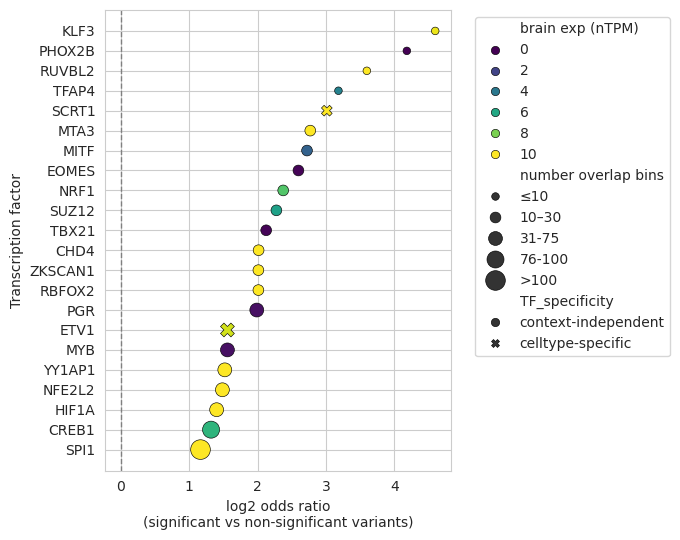

count    22.000000
mean      3.000000
std       1.380131
min       2.000000
25%       2.000000
50%       2.500000
75%       3.000000
max       7.000000
Name: sig_hit_variants, dtype: float64


In [ ]:
def build_tf_enrichment_plot_df(tf_enrich_hpa, pval_threshold=0.1):
    plot_df = tf_enrich_hpa[
        (tf_enrich_hpa["pval"] < pval_threshold) & (~tf_enrich_hpa["log2_OR"].isna())
    ].copy()
    plot_df = plot_df.sort_values("log2_OR", ascending=False)
    plot_df["brain exp (nTPM)"] = plot_df["brain_nTPM"].clip(lower=0, upper=10)
    plot_df["number overlap bins"] = pd.cut(
        plot_df["total_hit_variants"],
        bins=[0, 10, 30, 75, 100, np.inf],
        labels=["≤10", "10–30", "31-75", "76-100", ">100"],
    )
    return plot_df


def plot_tf_enrichment_scatter(plot_df, figsize):
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x="log2_OR",
        y="TF",
        hue="brain exp (nTPM)",
        style="TF_specificity",
        size="number overlap bins",
        size_order=["≤10", "10–30", "31-75", "76-100", ">100"],
        sizes=[30, 60, 100, 150, 200],
        palette="viridis",
        edgecolor="black",
        ax=ax,
    )
    plt.axvline(0, color="grey", linestyle="--", linewidth=1)
    plt.xlabel("log2 odds ratio\n(significant vs non-significant variants)")
    plt.ylabel("Transcription factor")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    return fig, ax


remap_2022_plot_df = build_tf_enrichment_plot_df(tf_enrich_hpa_remap2022)
fig, ax = plot_tf_enrichment_scatter(remap_2022_plot_df, figsize=(7, max(4, 0.25 * len(remap_2022_plot_df))))

writing = False
if writing:
    plt.savefig("/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/variant_overlapping_tfs/tf_enrichment_remap2022.png", dpi=300)
    plt.savefig("/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/variant_overlapping_tfs/tf_enrichment_remap2022.svg")
plt.show()

print(remap_2022_plot_df["sig_hit_variants"].describe())

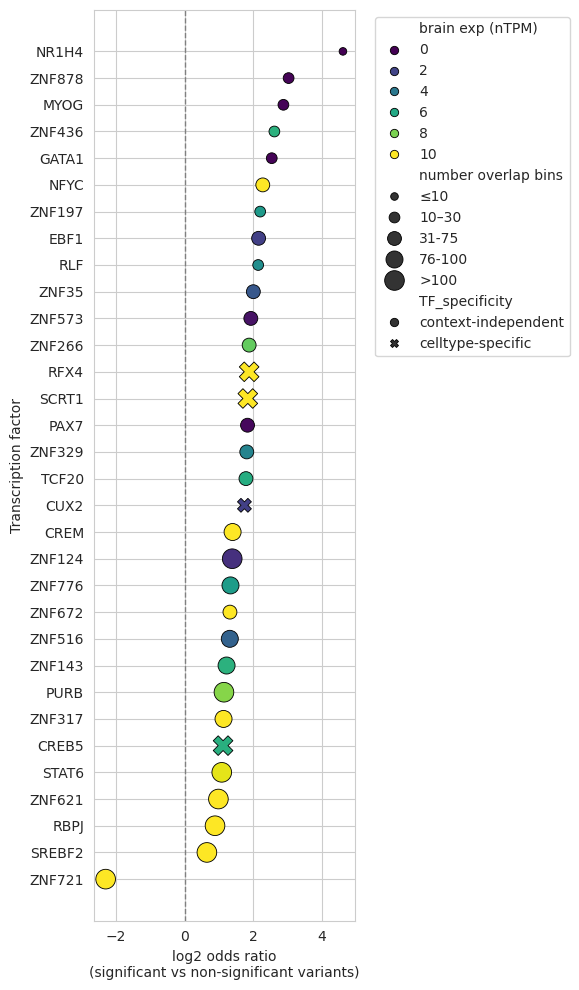

count    32.000000
mean      5.906250
std       4.651461
min       1.000000
25%       3.000000
50%       5.000000
75%       7.250000
max      24.000000
Name: sig_hit_variants, dtype: float64


In [ ]:
bitscore_plot_df = build_tf_enrichment_plot_df(tf_enrich_hpa_h13_fimo)

fig, ax = plot_tf_enrichment_scatter(bitscore_plot_df, figsize=(6, max(4, 0.25 * len(bitscore_plot_df) + 2)))

writing = False
if writing:
    plt.savefig("/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/variant_overlapping_tfs/tf_enrichment_fimo_h13.png", dpi=300)
    plt.savefig("/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/variant_overlapping_tfs/tf_enrichment_fimo_h13.svg")
plt.show()

print(bitscore_plot_df["sig_hit_variants"].describe())

In [ ]:
# supplementary table export
writing = False
if writing:
    with pd.ExcelWriter(
        "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/data/supplementary/variant_overlapping_TF_enrichment_results.xlsx",
        engine="openpyxl",
    ) as writer:
        tf_enrich_hpa_remap2022.to_excel(writer, sheet_name="remap2022", index=False)
        tf_enrich_hpa_h13_fimo.to_excel(writer, sheet_name="h13_fimo", index=False)

output_path_remap2022_plot_df = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/results/variant_info/remap2022_variant_overlap/2602_remap2022_tf_enriched_plot_df.tsv.gz"
output_path_h13_plot_df = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/results/variant_info/remap2022_variant_overlap/2602_remap2022_h13_tf_enriched_plot_df.tsv.gz"
if writing:
    remap_2022_plot_df.to_csv(output_path_remap2022_plot_df, sep="\t", index=False)
    bitscore_plot_df.to_csv(output_path_h13_plot_df, sep="\t", index=False)



### Compare bitscore and ReMap2022-based TFBS candidates

In [ ]:
remap_tfs = set(remap_2022_plot_df["TF"])
bitscore_tfs = set(bitscore_plot_df["TF"])
overlap_tfs = remap_tfs.intersection(bitscore_tfs)
print(f"Number of TFs in remap2022 plot: {len(remap_tfs)}")
print(f"Number of TFs in bitscore plot: {len(bitscore_tfs)}")
print(f"Number of TFs in both plots: {len(overlap_tfs)}")
print(f"TFs in both plots: {overlap_tfs}")

Number of TFs in remap2022 plot: 22
Number of TFs in bitscore plot: 32
Number of TFs in both plots: 1
TFs in both plots: {'SCRT1'}




### How many variants are overlapped by the enriched TF sets?

In [ ]:
n_sig_variants = NGN2_variants_with_gwas_tested["NGN2_variant_is_significant"].sum()

remap2022_associated_variants = NGN2_variants_with_gwas_tested[
    NGN2_variants_with_gwas_tested["has_remap2022_TFBS_overlap"] == True
].copy()
print(f"Number of variants with remap2022 TFBS overlap: {len(remap2022_associated_variants)}")
remap2022_associated_significant_variants = remap2022_associated_variants[
    remap2022_associated_variants["NGN2_variant_is_significant"] == True
].copy()
print(
    f"Number of significant variants with remap2022 TFBS overlap: "
    f"{len(remap2022_associated_significant_variants)} "
    f"({round(len(remap2022_associated_significant_variants) / n_sig_variants * 100, 2)}%)"
)

h13_fimo_associated_variants = NGN2_variants_with_gwas_tested[
    NGN2_variants_with_gwas_tested["local_bitscore_H13_motif_id"].notna()
].copy()
print(f"Number of variants with H13 motif overlap: {len(h13_fimo_associated_variants)}")
h13_fimo_associated_significant_variants = h13_fimo_associated_variants[
    h13_fimo_associated_variants["NGN2_variant_is_significant"] == True
].copy()
print(
    f"Number of significant variants with H13 motif overlap: "
    f"{len(h13_fimo_associated_significant_variants)} "
    f"({round(len(h13_fimo_associated_significant_variants) / n_sig_variants * 100, 2)}%)"
)

Number of variants with remap2022 TFBS overlap: 14377
Number of significant variants with remap2022 TFBS overlap: 387 (38.02%)
Number of variants with H13 motif overlap: 36345
Number of significant variants with H13 motif overlap: 965 (94.79%)




### Is one enriched TF set more highly expressed in brain than the other?

In [ ]:
remap_expr = remap_2022_plot_df["brain_nTPM"].dropna()
bitscore_expr = bitscore_plot_df["brain_nTPM"].dropna()
stat, p_value = mannwhitneyu(remap_expr, bitscore_expr, alternative="two-sided")
print(f"Mann-Whitney U test statistic: {stat}, p-value: {p_value}")

Mann-Whitney U test statistic: 415.0, p-value: 0.27096369682761823




### FDR-significant TF subsets (used below for the "enriched" TF-role comparisons)

/tmp/ipykernel_106052/2001064799.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_106052/2001064799.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


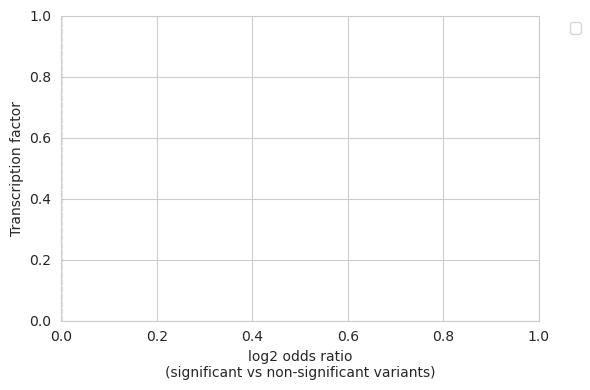

Empty DataFrame
Columns: [TF, log2_OR, fdr, brain_nTPM]
Index: []


In [ ]:
plot_df_bh_sig = tf_enrich_hpa_remap2022[tf_enrich_hpa_remap2022["fdr"] < 0.1].copy()
plot_df_bh_sig = plot_df_bh_sig.sort_values("log2_OR", ascending=False)
plot_df_bh_sig["brain_nTPM_clipped"] = plot_df_bh_sig["brain_nTPM"].clip(lower=0, upper=20)

plt.figure(figsize=(6, max(4, 0.25 * len(plot_df_bh_sig))))
sns.scatterplot(
    data=plot_df_bh_sig, x="log2_OR", y="TF", hue="brain_nTPM_clipped", style="TF_specificity",
    size="total_hit_variants", sizes=(30, 200), palette="viridis", edgecolor="black",
)
plt.axvline(0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("log2 odds ratio\n(significant vs non-significant variants)")
plt.ylabel("Transcription factor")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print(plot_df_bh_sig[["TF", "log2_OR", "fdr", "brain_nTPM"]])

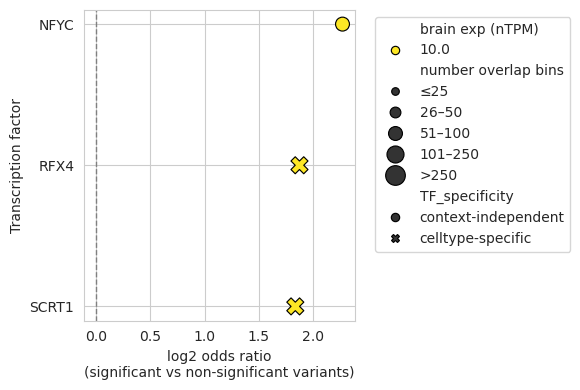

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

norm = Normalize(vmin=0, vmax=10)

plot_df_bh_sig_h13_fimo = tf_enrich_hpa_h13_fimo[tf_enrich_hpa_h13_fimo["fdr"] < 0.1].copy()

plot_df_bh_sig_h13_fimo = plot_df_bh_sig_h13_fimo.sort_values("log2_OR", ascending=False)
# Clip brain expression for color mapping
plot_df_bh_sig_h13_fimo["brain exp (nTPM)"] = plot_df_bh_sig_h13_fimo["brain_nTPM"].clip(lower=0, upper=10)


plot_df_bh_sig_h13_fimo["number overlap bins"] = pd.cut(
    plot_df_bh_sig_h13_fimo["total_hit_variants"],
    bins=[0, 25, 50, 100, 250, np.inf],
    labels=["≤25", "26–50", "51–100", "101–250", ">250"],
)


# plt.figure(figsize=(6, max(4, 0.25 * len(plot_df_bh_sig_h13_fimo))))

fig, ax = plt.subplots(figsize=(6, max(4, 0.25 * len(plot_df_bh_sig_h13_fimo))))

sns.scatterplot(
    data=plot_df_bh_sig_h13_fimo,
    x="log2_OR",
    y="TF",
    hue="brain exp (nTPM)",
    hue_norm=norm,
    style="TF_specificity",
    size="number overlap bins",
    size_order=["≤25", "26–50", "51–100", "101–250", ">250"],  # force order
    sizes=[30, 60, 100, 150, 200],  # explicit list matching size_order
    palette="viridis",
    edgecolor="black",
    ax=ax,
)


plt.axvline(0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("log2 odds ratio\n(significant vs non-significant variants)")
plt.ylabel("Transcription factor")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



### Mechanistic follow-up: does a loss or gain of a motif lead to a consistent direction of effect on activity?

In [28]:
def interprete_tf_role_from_mpra_for_remap(mpra_logfc, has_tfbs_annotation):
    """
    Interpret TF role based on MPRA logFC for the TF overlap from ReMap2022.
    ReMap2022 overlap alone doesn't tell us gain vs loss of binding, but a TFBS is
    more likely to be disrupted (lose affinity) than created by a random SNV, so
    absent further info we assume each overlapping variant reduces binding affinity.
    mpra_logfc > 0 means increased transcription initiation.
    """
    if not has_tfbs_annotation:
        return "no_tfbs_annotation"
    if pd.isna(mpra_logfc):
        return "no_variant_detected"
    if mpra_logfc > 0:
        return "repressing_TF_effect"
    elif mpra_logfc < 0:
        return "activating_TF_effect"
    else:
        return "no_effect_or_unclear"


NGN2_variant_annotation_data_tested_remap_overlap["TF_role_interpretation"] = (
    NGN2_variant_annotation_data_tested_remap_overlap.apply(
        lambda row: interprete_tf_role_from_mpra_for_remap(
            row["NGN2_variant_logFC"], row["has_remap2022_TFBS_overlap"]
        ),
        axis=1,
    )
)
print(NGN2_variant_annotation_data_tested_remap_overlap["TF_role_interpretation"].value_counts())

TF_role_interpretation
repressing_TF_effect    7753
activating_TF_effect    6624
Name: count, dtype: int64


In [ ]:
NGN2_variants_with_gwas_tested_with_annotation_fimoH13 = NGN2_variants_with_gwas_tested.loc[
    NGN2_variants_with_gwas_tested["local_bitscore_H13_motif_id"].notna()
].copy()
NGN2_variants_with_gwas_tested_with_annotation_fimoH13["TF_role_interpretation"] = (
    NGN2_variants_with_gwas_tested_with_annotation_fimoH13.apply(
        lambda row: interprete_tf_role_from_mpra_and_bitscore(
            row["NGN2_variant_logFC"], row["local_bitscore_delta_local_bit_score"]
        ),
        axis=1,
    )
)



### Per-TF functional bias: is each TF consistently associated with activating or repressing effects?

In [ ]:
def plot_histogram_of_tf_functional_bias(df_tf_grouped, title="TF Functional Bias Histogram"):
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_tf_grouped, x="proportion_activating", bins=20, kde=True)
    plt.xlabel("Proportion of activator-like variants")
    plt.ylabel("Number of TFs")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_tf_interpretation_summary(tf_name, n_activating, n_repressing, min_observations=2, threshold_proportion=0.7):
    if (n_activating + n_repressing) < min_observations:
        return "not_enough_data"
    proportion_activating = n_activating / (n_activating + n_repressing)
    if proportion_activating >= threshold_proportion:
        return "predicted_activator"
    elif proportion_activating <= (1 - threshold_proportion):
        return "predicted_repressor"
    else:
        return "context_dependent"


def compute_relative_functional_interpretation_tf(
    df, title, gene_symbol_col="local_bitscore_tf_gene_symbol", threshold_proportion=0.7
):
    print(title)
    df_tf_grouped = (
        df.groupby(gene_symbol_col)["TF_role_interpretation"]
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )
    # Guard against an empty/degenerate subset (e.g. no TF meets both the
    # "significant" and "enriched" criteria): unstack() then has no
    # activating/repressing columns at all rather than all-zero columns.
    for col in ("activating_TF_effect", "repressing_TF_effect"):
        if col not in df_tf_grouped.columns:
            df_tf_grouped[col] = 0
    df_tf_grouped["total_counts"] = df_tf_grouped[
        [col for col in df_tf_grouped.columns if "effect" in col]
    ].sum(axis=1)
    df_tf_grouped["interpretation_summary"] = df_tf_grouped.apply(
        lambda row: get_tf_interpretation_summary(
            row[gene_symbol_col],
            row.get("activating_TF_effect", 0),
            row.get("repressing_TF_effect", 0),
            min_observations=2,
            threshold_proportion=threshold_proportion,
        ),
        axis=1,
    )
    print("All considered TFBS: ", df_tf_grouped["interpretation_summary"].value_counts())
    print("All considered TFBS normalized: ", df_tf_grouped["interpretation_summary"].value_counts(normalize=True))

    df_tf_grouped = df_tf_grouped[df_tf_grouped["total_counts"] >= 2].copy()
    print("Filtered TFBS: ", df_tf_grouped["interpretation_summary"].value_counts())
    print("Filtered TFBS normalized: ", df_tf_grouped["interpretation_summary"].value_counts(normalize=True))

    df_tf_grouped["proportion_activating"] = df_tf_grouped["activating_TF_effect"] / df_tf_grouped["total_counts"]
    df_tf_grouped["proportion_repressing"] = df_tf_grouped["repressing_TF_effect"] / df_tf_grouped["total_counts"]
    return df_tf_grouped

In [ ]:
# ReMap2022 subsets: all / significant / enriched / significant-enriched
df_tf_grouped_remap = compute_relative_functional_interpretation_tf(
    NGN2_variant_annotation_data_tested_remap_overlap,
    title="All variants with TFBS annotation",
    gene_symbol_col="remap2022_TFBS_name_variant_overlapping",
)

df_tf_sig_remap = NGN2_variant_annotation_data_tested_remap_overlap.loc[
    NGN2_variant_annotation_data_tested_remap_overlap["NGN2_variant_is_significant"]
].copy()
df_tf_sig_grouped_remap = compute_relative_functional_interpretation_tf(
    df_tf_sig_remap, title="Significant variants with TFBS annotation",
    gene_symbol_col="remap2022_TFBS_name_variant_overlapping",
)

df_tf_enr_remap = NGN2_variant_annotation_data_tested_remap_overlap.loc[
    NGN2_variant_annotation_data_tested_remap_overlap["remap2022_TFBS_name_variant_overlapping"].isin(
        remap_2022_plot_df["TF"]
    )
].copy()
df_tf_enr_grouped_remap = compute_relative_functional_interpretation_tf(
    df_tf_enr_remap, title="Enriched TFBS overlaps for variants",
    gene_symbol_col="remap2022_TFBS_name_variant_overlapping",
)

df_tf_sig_enr_remap = NGN2_variant_annotation_data_tested_remap_overlap.loc[
    NGN2_variant_annotation_data_tested_remap_overlap["remap2022_TFBS_name_variant_overlapping"].isin(
        plot_df_bh_sig["TF"]
    )
].copy()

df_tf_sig_enr_grouped_remap = compute_relative_functional_interpretation_tf(
    df_tf_sig_enr_remap, title="Significant enriched TFBS with variants",
    gene_symbol_col="remap2022_TFBS_name_variant_overlapping",
)

All variants with TFBS annotation
All considered TFBS:  interpretation_summary
context_dependent      500
predicted_repressor    120
not_enough_data        113
predicted_activator     69
Name: count, dtype: int64
All considered TFBS normalized:  interpretation_summary
context_dependent      0.623441
predicted_repressor    0.149626
not_enough_data        0.140898
predicted_activator    0.086035
Name: proportion, dtype: float64
Filtered TFBS:  interpretation_summary
context_dependent      500
predicted_repressor    120
predicted_activator     69
Name: count, dtype: int64
Filtered TFBS normalized:  interpretation_summary
context_dependent      0.725689
predicted_repressor    0.174165
predicted_activator    0.100145
Name: proportion, dtype: float64
Significant variants with TFBS annotation
All considered TFBS:  interpretation_summary
not_enough_data        133
context_dependent       39
predicted_repressor     33
predicted_activator     14
Name: count, dtype: int64
All considered TFBS norm

In [32]:
df_tf_grouped_fimoH13 = compute_relative_functional_interpretation_tf(
    NGN2_variants_with_gwas_tested_with_annotation_fimoH13, title="All variants with TFBS annotation"
)

df_tf_sig_fimoH13 = NGN2_variants_with_gwas_tested_with_annotation_fimoH13.loc[
    NGN2_variants_with_gwas_tested_with_annotation_fimoH13["NGN2_variant_is_significant"]
].copy()
df_tf_sig_grouped_fimoH13 = compute_relative_functional_interpretation_tf(
    df_tf_sig_fimoH13, title="Significant variants with TFBS annotation"
)

df_tf_enr_fimoH13 = NGN2_variants_with_gwas_tested_with_annotation_fimoH13.loc[
    NGN2_variants_with_gwas_tested_with_annotation_fimoH13["local_bitscore_tf_gene_symbol"].isin(
        bitscore_plot_df["TF"]
    )
].copy()
df_tf_enr_grouped_fimoH13 = compute_relative_functional_interpretation_tf(
    df_tf_enr_fimoH13, title="Enriched TFBS overlaps for variants"
)

df_tf_sig_enr_fimoH13 = NGN2_variants_with_gwas_tested_with_annotation_fimoH13.loc[
    NGN2_variants_with_gwas_tested_with_annotation_fimoH13["local_bitscore_tf_gene_symbol"].isin(
        plot_df_bh_sig_h13_fimo["TF"]
    )
].copy()
df_tf_sig_enr_grouped_fimoH13 = compute_relative_functional_interpretation_tf(
    df_tf_sig_enr_fimoH13, title="Significant enriched TFBS with variants"
)

All variants with TFBS annotation
All considered TFBS:  interpretation_summary
context_dependent      541
predicted_repressor     29
predicted_activator     20
not_enough_data          3
Name: count, dtype: int64
All considered TFBS normalized:  interpretation_summary
context_dependent      0.912310
predicted_repressor    0.048904
predicted_activator    0.033727
not_enough_data        0.005059
Name: proportion, dtype: float64
Filtered TFBS:  interpretation_summary
context_dependent      541
predicted_repressor     29
predicted_activator     20
Name: count, dtype: int64
Filtered TFBS normalized:  interpretation_summary
context_dependent      0.916949
predicted_repressor    0.049153
predicted_activator    0.033898
Name: proportion, dtype: float64
Significant variants with TFBS annotation
All considered TFBS:  interpretation_summary
not_enough_data        160
context_dependent       90
predicted_activator     57
predicted_repressor     34
Name: count, dtype: int64
All considered TFBS norm

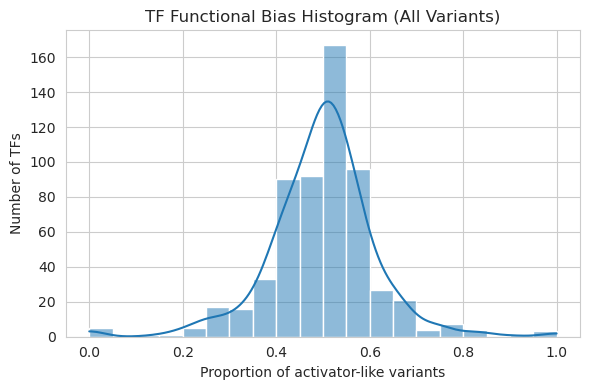

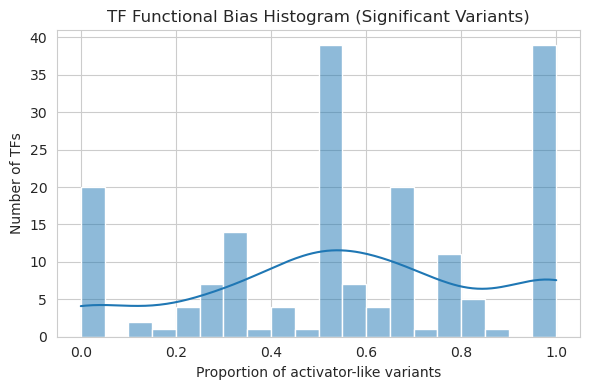

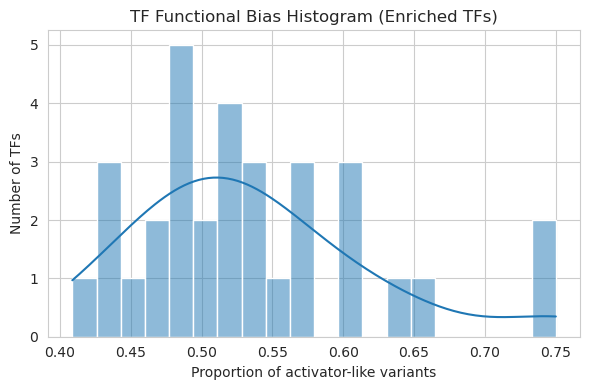

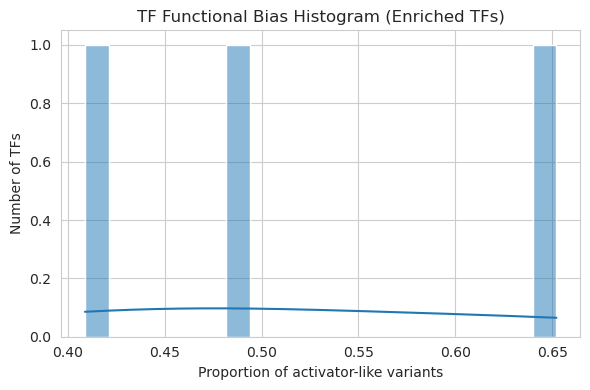

In [ ]:
plot_histogram_of_tf_functional_bias(df_tf_grouped_fimoH13, title="TF Functional Bias Histogram (All Variants)")
plot_histogram_of_tf_functional_bias(df_tf_sig_grouped_fimoH13, title="TF Functional Bias Histogram (Significant Variants)")
plot_histogram_of_tf_functional_bias(df_tf_enr_grouped_fimoH13, title="TF Functional Bias Histogram (Enriched TFs)")
plot_histogram_of_tf_functional_bias(df_tf_sig_enr_grouped_fimoH13, title="TF Functional Bias Histogram (Enriched TFs)")



### Merge the TF functional-bias interpretation back onto the variant-level table

In [34]:
NGN2_variants_with_gwas_tested = NGN2_variants_with_gwas_tested.merge(
    df_tf_sig_grouped_fimoH13[
        ["local_bitscore_tf_gene_symbol", "proportion_activating", "total_counts", "interpretation_summary"]
    ],
    on="local_bitscore_tf_gene_symbol",
    how="left",
)


def annotate_not_enought_data(row, interpretation_col="interpretation_summary", tf_overlap_annotation_col="local_bitscore_tf_gene_symbol"):
    # if the interpretation is missing but the TF overlap annotation itself is not
    # NA, the TF simply wasn't observed at least twice (not_enough_data), rather
    # than genuinely having no TFBS annotation.
    if pd.isna(row[interpretation_col]) and pd.notna(row[tf_overlap_annotation_col]):
        return "not_enough_data"
    return row[interpretation_col]


NGN2_variants_with_gwas_tested["interpretation_summary"] = NGN2_variants_with_gwas_tested.apply(
    annotate_not_enought_data, axis=1
)
print(NGN2_variants_with_gwas_tested["interpretation_summary"].value_counts())

interpretation_summary
context_dependent      13740
not_enough_data        12435
predicted_activator     5827
predicted_repressor     4343
Name: count, dtype: int64




### TF classification proportions: ReMap2022 vs FIMO/H13, all vs significant variants

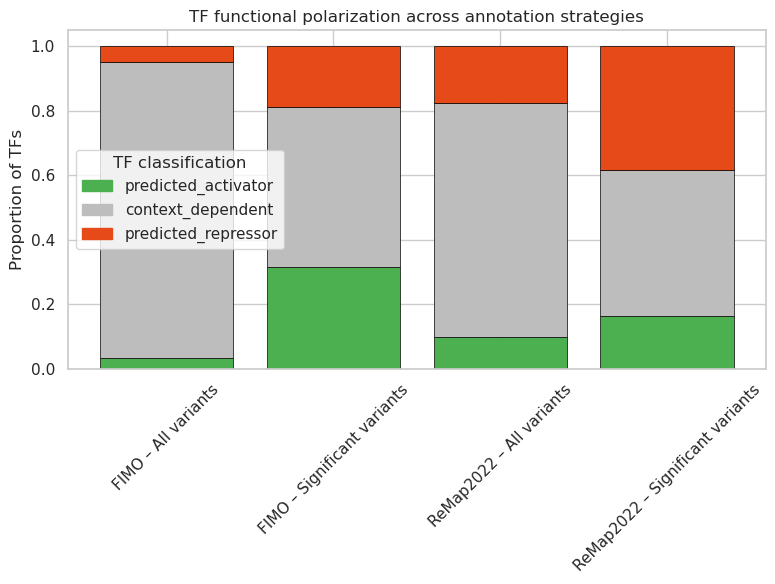

In [ ]:
def prepare_summary(df, annotation, subset):
    summary = df["interpretation_summary"].value_counts(normalize=True).reset_index()
    summary.columns = ["interpretation_summary", "proportion"]
    summary["annotation"] = annotation
    summary["subset"] = subset
    return summary


plot_df = pd.concat([
    prepare_summary(df_tf_grouped_fimoH13, "FIMO", "All variants"),
    prepare_summary(df_tf_sig_grouped_fimoH13, "FIMO", "Significant variants"),
    prepare_summary(df_tf_grouped_remap, "ReMap2022", "All variants"),
    prepare_summary(df_tf_sig_grouped_remap, "ReMap2022", "Significant variants"),
])

category_order = ["predicted_activator", "context_dependent", "predicted_repressor"]
color_map = {"predicted_activator": "#4CAF50", "context_dependent": "#BDBDBD", "predicted_repressor": "#E64A19"}
annotation_order = ["FIMO", "ReMap2022"]
subset_order = ["All variants", "Significant variants"]

plot_df["interpretation_summary"] = pd.Categorical(plot_df["interpretation_summary"], categories=category_order, ordered=True)
plot_df["label"] = plot_df["annotation"] + " – " + plot_df["subset"]
label_order = [f"{a} – {s}" for a in annotation_order for s in subset_order]

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))
for label in label_order:
    subset_df = plot_df[plot_df["label"] == label]
    bottom = 0
    for category in category_order:
        value = subset_df.loc[subset_df["interpretation_summary"] == category, "proportion"]
        if not value.empty:
            ax.bar(label, value.values[0], bottom=bottom, color=color_map[category], edgecolor="black", linewidth=0.5)
            bottom += value.values[0]

ax.set_ylabel("Proportion of TFs")
ax.set_xlabel("")
ax.set_title("TF functional polarization across annotation strategies")
plt.xticks(rotation=45)
plt.tight_layout()
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[c]) for c in category_order]
ax.legend(handles, category_order, title="TF classification")
plt.show()

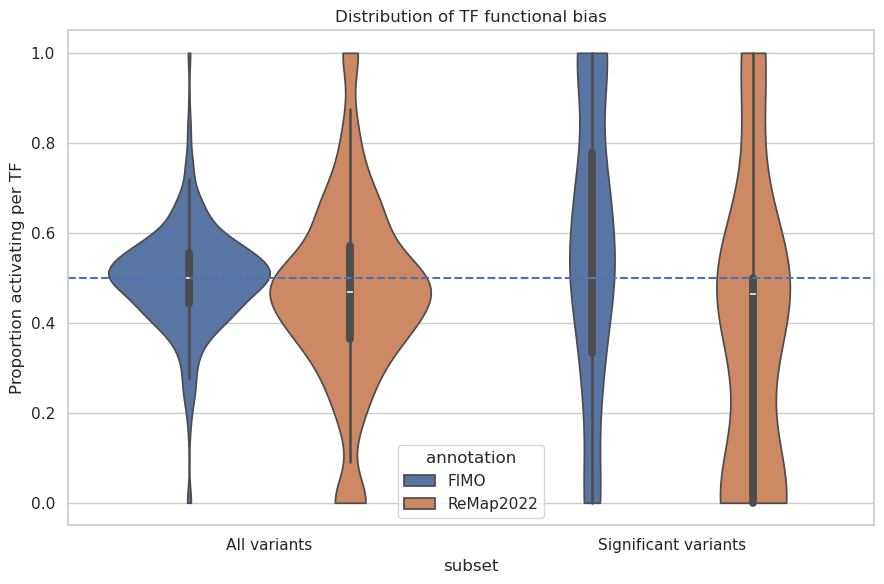

In [36]:
def add_labels(df, annotation, subset):
    df_copy = df.copy()
    df_copy["annotation"] = annotation
    df_copy["subset"] = subset
    return df_copy


violin_df = pd.concat([
    add_labels(df_tf_grouped_fimoH13, "FIMO", "All variants"),
    add_labels(df_tf_sig_grouped_fimoH13, "FIMO", "Significant variants"),
    add_labels(df_tf_grouped_remap, "ReMap2022", "All variants"),
    add_labels(df_tf_sig_grouped_remap, "ReMap2022", "Significant variants"),
])

plt.figure(figsize=(9, 6))
sns.violinplot(data=violin_df, x="subset", y="proportion_activating", hue="annotation", cut=0, inner="box")
plt.axhline(0.5, linestyle="--")
plt.ylabel("Proportion activating per TF")
plt.title("Distribution of TF functional bias")
plt.tight_layout()
plt.show()

In [37]:
u, p = mannwhitneyu(
    df_tf_grouped_fimoH13["proportion_activating"],
    df_tf_sig_grouped_fimoH13["proportion_activating"],
    alternative="two-sided",
)
print("FIMO all vs significant p =", p)

FIMO all vs significant p = 0.0003051963199780618


In [38]:
output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/results/variant_info/2601_NGN2_variants_with_tfbs_enrichment_and_interpretation.tsv.gz"
writing = False
if writing:
    NGN2_variants_with_gwas_tested.to_csv(output_path, sep="\t", index=False)
print(f"Wrote {NGN2_variants_with_gwas_tested.shape[0]} rows x {NGN2_variants_with_gwas_tested.shape[1]} columns to {output_path}")

Wrote 38968 rows x 208 columns to /home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/results/variant_info/2601_NGN2_variants_with_tfbs_enrichment_and_interpretation.tsv.gz
